In [2]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern

In [3]:
#Function 7
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 7.csv') 
columns = ['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Input 5', 'Input 6', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.004636, 0.207768, 0.404112, 0.351555, 0.401196, 0.792288,
                     2.0203487535312235])
data.loc[len(data)] = new_data7
#Add Week 8's data to our pandas dataframe
new_data8 = np.array([0.026756, 0.059727, 0.449213, 0.390822, 0.344762, 0.772857,
                     2.246426597825821])
data.loc[len(data)] = new_data8
data
#Add Week 9's data to our pandas dataframe
new_data9 = np.array([0.000814, 0.012686, 0.415064, 0.520644, 0.332606, 0.845142,
                     1.148647288259179])
data.loc[len(data)] = new_data9
#Add Week 10's data to our pandas dataframe
new_data10 = np.array([0.062188, 0.108207, 0.564947, 0.226737, 0.344570, 0.751893,
                     2.703020381612213])
data.loc[len(data)] = new_data10
data

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Outputs
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Input 5'
                  ,'Input 6']])
Y = np.array(data[['Outputs']])

# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Outputs
Input 1,1.000000,0.048984,-0.137407,0.111831,0.075978,-0.606295,-0.569277
Input 2,0.048984,1.000000,-0.076385,0.108877,0.320858,0.058763,-0.257914
Input 3,-0.137407,-0.076385,1.000000,0.233511,-0.272010,0.043858,0.090332
Input 4,0.111831,0.108877,0.233511,1.000000,0.122948,-0.145854,-0.266663
Input 5,0.075978,0.320858,-0.272010,0.122948,1.000000,-0.005374,-0.266561
Input 6,-0.606295,0.058763,0.043858,-0.145854,-0.005374,1.000000,0.460760
Outputs,-0.569277,-0.257914,0.090332,-0.266663,-0.266561,0.460760,1.000000


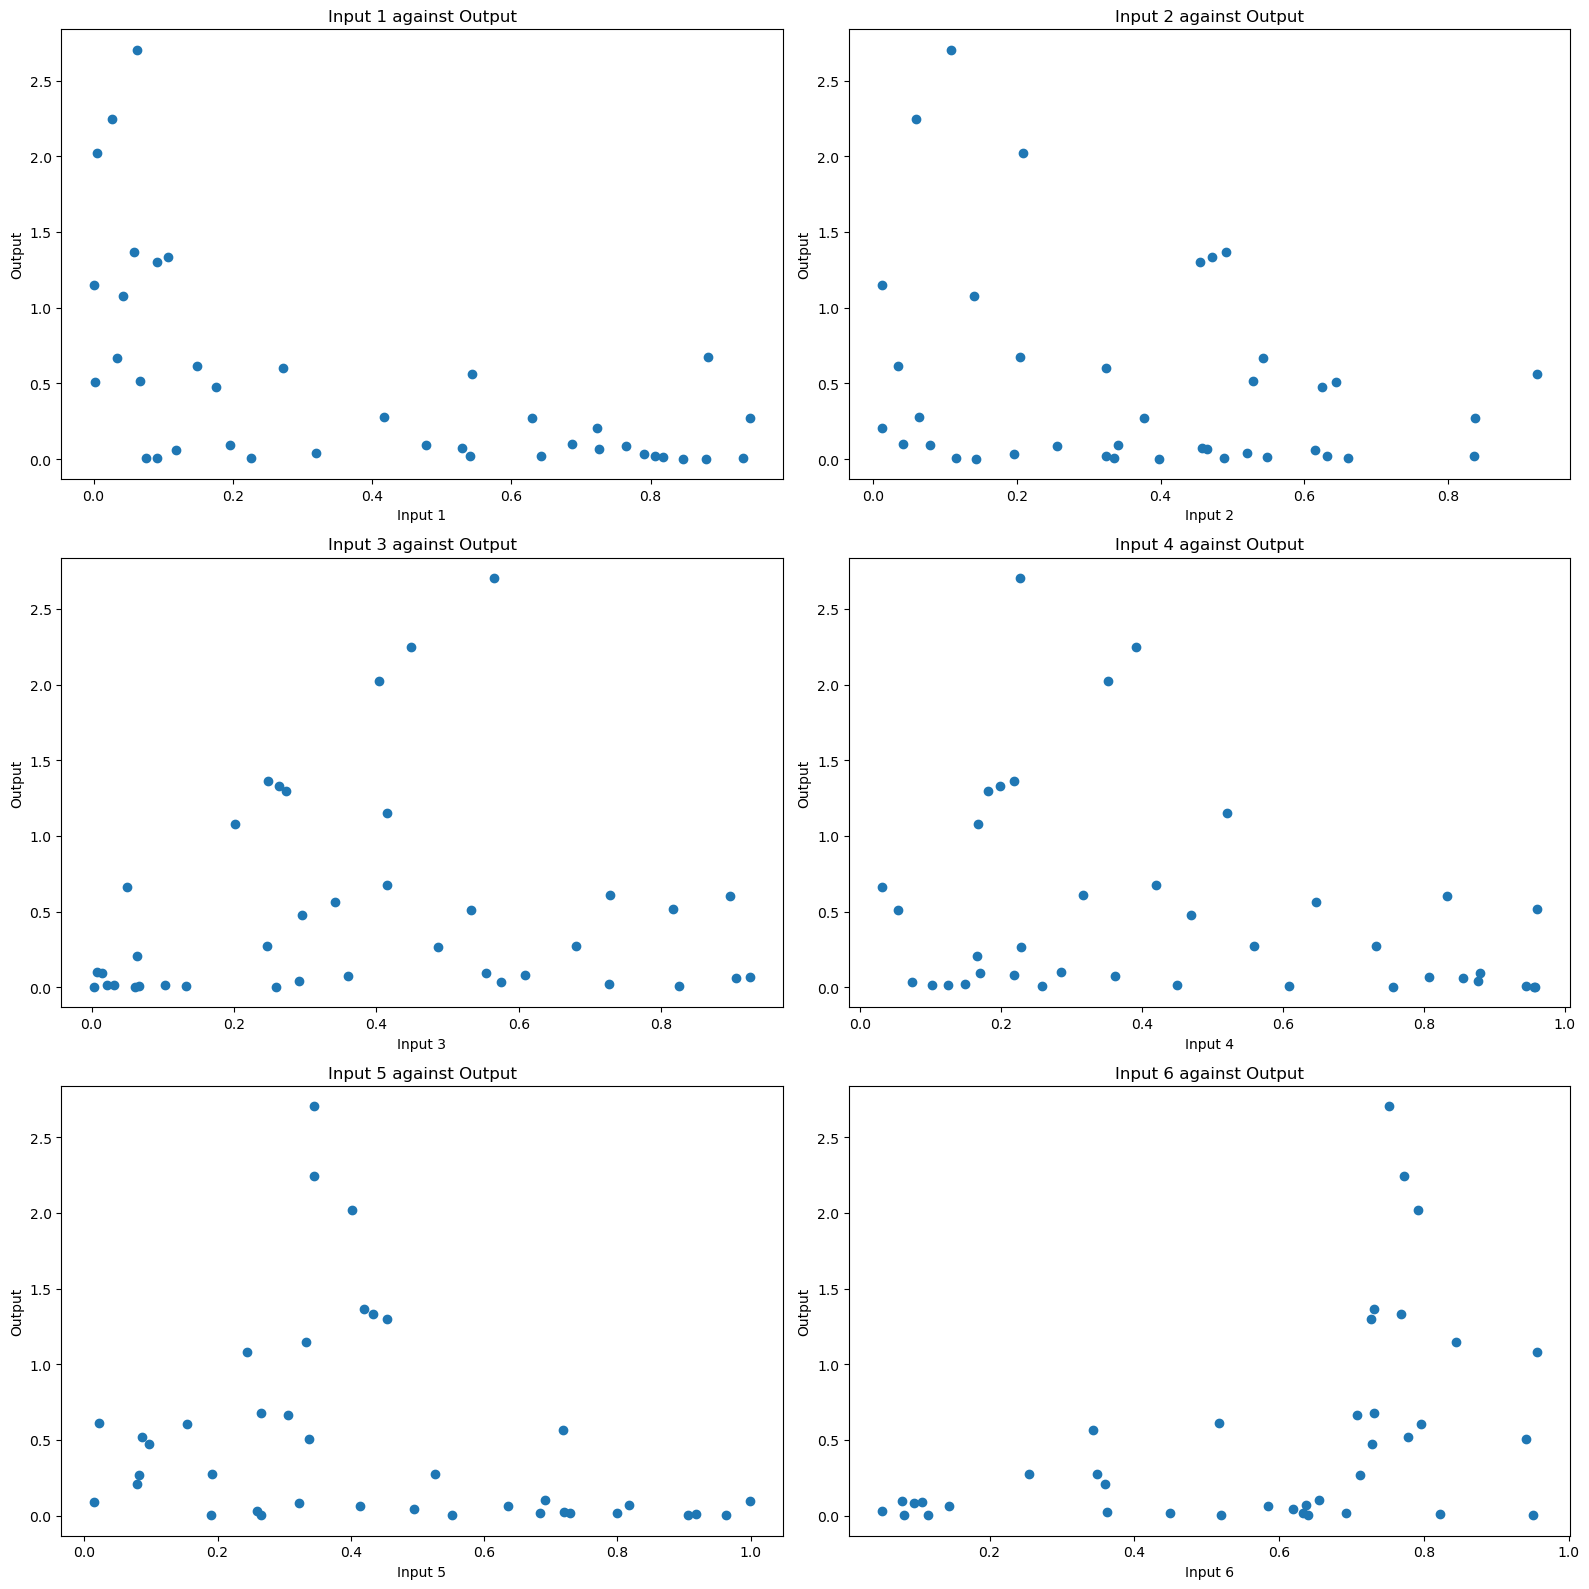

In [5]:
#Plotting each Input against the output
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,2, figsize = (16,16))

ax[0][0].scatter(X[:,0], Y)
ax[0][1].scatter(X[:,1], Y)
ax[1][0].scatter(X[:,2], Y)
ax[1][1].scatter(X[:,3], Y)
ax[2][0].scatter(X[:,4], Y)
ax[2][1].scatter(X[:,5], Y)

#Creating titles and axis labels
ax[0][0].set_title('Input 1 against Output')
ax[0][1].set_title('Input 2 against Output')
ax[1][0].set_title('Input 3 against Output')
ax[1][1].set_title('Input 4 against Output')
ax[2][0].set_title('Input 5 against Output')
ax[2][1].set_title('Input 6 against Output')

ax[0][0].set_xlabel('Input 1')
ax[0][0].set_ylabel('Output')

ax[0][1].set_xlabel('Input 2')
ax[0][1].set_ylabel('Output')

ax[1][0].set_xlabel('Input 3')
ax[1][0].set_ylabel('Output')

ax[1][1].set_xlabel('Input 4')
ax[1][1].set_ylabel('Output')

ax[2][0].set_xlabel('Input 5')
ax[2][0].set_ylabel('Output')

ax[2][1].set_xlabel('Input 6')
ax[2][1].set_ylabel('Output')

plt.tight_layout()
plt.show()

In [6]:
#We now use random forest regression to generate a list of promising points for a GP
#to evaluate
from sklearn.ensemble import RandomForestRegressor
#Using randomized search CV for light hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.5, 0.7, 1.0]
}

rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1, random_state = 42)

search.fit(X, Y.ravel())

rf_best = search.best_estimator_
print("Tuned RF Model:", rf_best)

Tuned RF Model: RandomForestRegressor(max_features=0.5, n_estimators=200, n_jobs=-1,
                      random_state=42)


In [7]:
#Use latin hypercube sampling to create a grid 
d = 6
n = 300000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Use random forest model to outputs from the grid
Y_pred = rf_best.predict(grid)

#Select the top 300 points
n_select = 300
top_idx = np.argsort(Y_pred)[-n_select:]
X_candidates = grid[top_idx]

In [8]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)

gp.fit(X,Y)



#fit GP to candidate points suggested by Random Forest model
mu, std = gp.predict(X_candidates, return_std = True)

#fit GP to candidate points generated over entire domain
mu_grid, std_grid = gp.predict(grid, return_std = True)

In [10]:
#Calculate UCB 
beta = 1.96 #set exploration parameter
UCB = mu + beta*std 
UCB_grid = mu_grid + beta*std_grid 
#Find point selected by random forest model that maximises UCB
X_next = X_candidates[np.argmax(UCB)]
#Find point over entire domain that maximises UCB
X_next_grid = grid[np.argmax(UCB_grid)]
print("Random Forest Hybrid model next suggested point:", np.round(X_next,6))
print("Pure GP model next suggested point:", np.round(X_next_grid,6))

Random Forest Hybrid model next suggested point: [0.035266 0.12155  0.61527  0.250095 0.46784  0.732755]
Pure GP model next suggested point: [0.041806 0.029798 0.569797 0.235414 0.354671 0.692631]
